# <font color="#0b486b">  FIT5215: Deep Learning (2026)</font>
***


Faculty of Information Technology, Monash University, Australia
***

# <font color="#0b486b">Deep Neural Networks</font>


## <font color="#0b486b">Part 1: Theory and Knowledge Questions</font>


The first part of this assignment is to demonstrate your knowledge in deep learning that you have acquired from the lectures and tutorials materials. Most of the contents in this assignment are drawn from **the lectures and tutorials from weeks 1 to 4**. Going through these materials before attempting this part is highly recommended.

####  <font color="red">**Question 1.1**</font> **Activation function plays an important role in modern Deep NNs. For each of the activation functions below, state its output range, find its derivative (show your steps), and plot the activation fuction and its derivative**

<font color="red">**(a)**</font> Exponential linear unit (ELU): $\text{ELU}(x)=\begin{cases}
0.1\left(\exp(x)-1\right) & \text{if}\,x\leq0\\
x & \text{if}\,x>0
\end{cases}$





#### **(a) Exponential linear unit (ELU)**

**1. Output Range**
The ELU function is defined piecewise. To find the output range, we evaluate the limits for both conditions:
- **For $x > 0$:** The function is $f(x) = x$. 
  Taking the limit as $x$ approaches positive infinity:
  $$\lim_{x \to +\infty} x = +\infty$$
- **For $x \le 0$:** The function is $f(x) = 0.1(\exp(x) - 1)$. 
  Taking the limit as $x$ approaches negative infinity:
  $$\lim_{x \to -\infty} 0.1(\exp(x) - 1) = 0.1(0 - 1) = -0.1$$
  Since the function is continuous and strictly increasing, its minimum value is bounded by $-0.1$ (exclusive) and it reaches $+\infty$.

**Output Range:** $(-0.1, +\infty)$

**2. Derivative**
We take the derivative with respect to $x$ for both parts separately:
- **For $x > 0$:**
  $$f(x) = x$$
  $$\frac{d}{dx} f(x) = \frac{d}{dx} (x) = 1$$
- **For $x \le 0$:**
  $$f(x) = 0.1(\exp(x) - 1) = 0.1\exp(x) - 0.1$$
  Applying the derivative rules (the derivative of a constant is $0$, and the derivative of $\exp(x)$ is $\exp(x)$):
  $$\frac{d}{dx} f(x) = \frac{d}{dx} (0.1\exp(x)) - \frac{d}{dx} (0.1)$$
  $$\frac{d}{dx} f(x) = 0.1\exp(x) - 0 = 0.1\exp(x)$$

**Derivative:**
$$\text{ELU}'(x) = \begin{cases} 0.1\exp(x) & \text{if } x \le 0 \\ 1 & \text{if } x > 0 \end{cases}$$


<font color="red">**(b)**</font> Gaussian Error Linear Unit (GELU): $\text{GELU}(x)=x\Phi(x)$ where $\Phi(x)$ is the `probability cummulative function` of the standard Gaussian distribution or $\Phi(x) = \mathbb{P}\left(X\leq x\right)$ where $X \sim N\left(0,1\right)$. In addition, the GELU activation fuction (the link for the [main paper](https://arxiv.org/pdf/1606.08415v5.pdf)) has been widely used in the state-of-the-art Vision for Transformers (e.g., here is the link for [the main ViT paper](https://arxiv.org/pdf/2010.11929v2.pdf)).


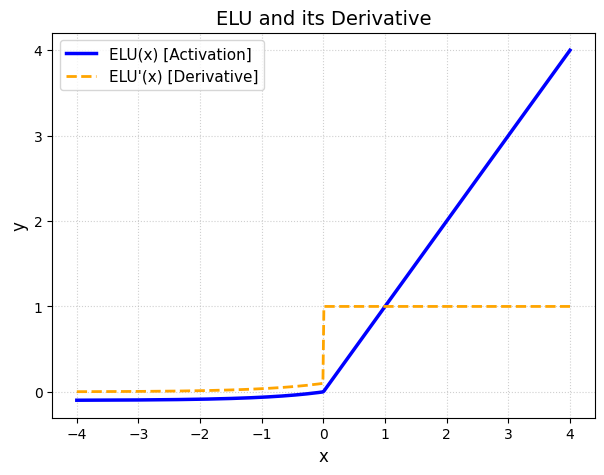

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

x = np.linspace(-4, 4, 500)

def elu(x, alpha=0.1):
    return np.where(x > 0, x, alpha * (np.exp(x) - 1))

def elu_derivative(x, alpha=0.1):
    return np.where(x > 0, 1, alpha * np.exp(x))

plt.figure(figsize=(7, 5))
plt.plot(x, elu(x), label="ELU(x) [Activation]", color='blue', linewidth=2.5)
plt.plot(x, elu_derivative(x), label="ELU'(x) [Derivative]", color='orange', linestyle='--', linewidth=2)
plt.title("ELU and its Derivative", fontsize=14)
plt.xlabel("x", fontsize=12)
plt.ylabel("y", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.show()  





#### **(b) Gaussian Error Linear Unit (GELU)**

**1. Output Range**
The GELU function is defined as $\text{GELU}(x) = x\Phi(x)$, where $\Phi(x)$ is the cumulative distribution function (CDF) of the standard Gaussian distribution $\mathcal{N}(0, 1)$. To find the output range, we evaluate its limits and the global minimum:
- **As $x \to +\infty$:**
  The CDF approaches $1$, so:
  $$\lim_{x \to +\infty} \Phi(x) = 1$$
  $$\lim_{x \to +\infty} x\Phi(x) = +\infty \times 1 = +\infty$$
- **As $x \to -\infty$:**
  The CDF approaches $0$:
  $$\lim_{x \to -\infty} \Phi(x) = 0$$
  This creates an indeterminate form ($-\infty \times 0$). However, because the CDF $\Phi(x)$ decays exponentially to $0$ (which is much faster than the linear growth of $x$), the limit evaluates to $0$:
  $$\lim_{x \to -\infty} x\Phi(x) = 0$$
- **Global Minimum:**
  For $x < 0$, $x$ is negative and $\Phi(x)$ is strictly positive, making $\text{GELU}(x)$ negative. The function reaches a global minimum before decaying back to $0$. By setting its derivative to zero ($\text{GELU}'(x) = 0$), the minimum occurs at $x \approx -0.7518$, yielding a minimum value of approximately $-0.1700$.

**Output Range:** $[-0.17, +\infty)$

**2. Derivative**
Let $f(x) = x\Phi(x)$. To find the derivative, we apply the product rule for differentiation: $\frac{d}{dx}[u \cdot v] = u'v + uv'$.
- Let $u = x$, then the derivative is $u' = \frac{d}{dx}(x) = 1$.
- Let $v = \Phi(x)$. By the Fundamental Theorem of Calculus, the derivative of the cumulative distribution function (CDF) is the probability density function (PDF), denoted as $\phi(x)$. So, $v' = \frac{d}{dx}(\Phi(x)) = \phi(x)$.

Applying the product rule:
$$\frac{d}{dx} \text{GELU}(x) = \frac{d}{dx} (x \cdot \Phi(x))$$
$$\frac{d}{dx} \text{GELU}(x) = \left( \frac{d}{dx}(x) \right) \Phi(x) + x \left( \frac{d}{dx}\Phi(x) \right)$$
$$\frac{d}{dx} \text{GELU}(x) = 1 \cdot \Phi(x) + x \cdot \phi(x)$$

**Derivative:**
$$\text{GELU}'(x) = \Phi(x) + x\phi(x)$$
*(Note: $\phi(x)$ is the PDF of the standard Gaussian distribution, $\phi(x) = \frac{1}{\sqrt{2\pi}}\exp(-\frac{x^2}{2})$)*



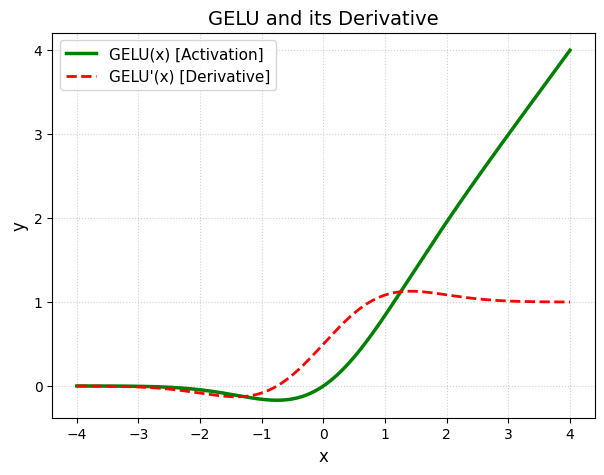

In [ ]:
def gelu(x):
    return x * norm.cdf(x)

def gelu_derivative(x):
    return norm.cdf(x) + x * norm.pdf(x)

plt.figure(figsize=(7, 5))
plt.plot(x, gelu(x), label="GELU(x) [Activation]", color='green', linewidth=2.5)
plt.plot(x, gelu_derivative(x), label="GELU'(x) [Derivative]", color='red', linestyle='--', linewidth=2)
plt.title("GELU and its Derivative", fontsize=14)
plt.xlabel("x", fontsize=12)
plt.ylabel("y", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.show()  

####  <font color="red">**Question 1.2:**</font> **Assume that we feed a data point $x$ with a ground-truth label $y=2$ to the feed-forward neural network with the `ReLU activation` function as shown in the following figure**


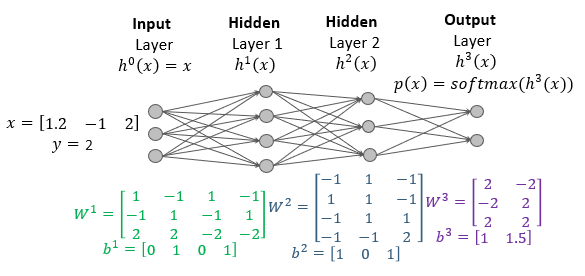

<font color="red">**(a)**</font>  What is the numerical value of the latent presentation $h^1(x)$?




First, we compute the linear transformation $z^1 = x \cdot W^1 + b^1$:


$$z^1 = [1.2, -1, 2] \times \begin{bmatrix} 1 & -1 & 1 & -1 \\ -1 & 1 & -1 & 1 \\ 2 & 2 & -2 & -2 \end{bmatrix} + [0, 1, 0, 1]$$

$$z^1 = [6.2, 1.8, -1.8, -6.2] + [0, 1, 0, 1]$$

$$z^1 = [6.2, 2.8, -1.8, -5.2]$$

Next, we apply the ReLU activation function $h^1(x) = \max(0, z^1)$:


$$h^1(x) = [\max(0, 6.2), \max(0, 2.8), \max(0, -1.8), \max(0, -5.2)]$$

$$h^1(x) = [6.2, 2.8, 0, 0]$$

In [3]:
import torch
import torch.nn.functional as F
x = torch.tensor([[1.2, -1.0, 2.0]])
W1 = torch.tensor([
    [ 1.0, -1.0,  1.0, -1.0],
    [-1.0,  1.0, -1.0,  1.0],
    [ 2.0,  2.0, -2.0, -2.0]
])
b1 = torch.tensor([[0.0, 1.0, 0.0, 1.0]])

z1 = torch.matmul(x, W1) + b1
h1 = F.relu(z1)

print("h1(x) =", h1.numpy())

h1(x) = [[6.2 2.8 0.  0. ]]


<font color="red">**(b)**</font>  What is the numerical value of the latent presentation $h^2(x)$?



Based on the output from the previous layer, $h^1(x) = [6.2, 2.8, 0, 0]$, we compute the linear transformation for the second layer $z^2 = h^1(x) \cdot W^2 + b^2$:

$$z^2 = [6.2, 2.8, 0, 0] \times \begin{bmatrix} -1 & 1 & -1 \\ 1 & 1 & -1 \\ -1 & -1 & 1 \\ -1 & -1 & 2 \end{bmatrix} + [1, 0, 1]$$

Calculating the matrix multiplication:
$$z^2 = [(-6.2 + 2.8), (6.2 + 2.8), (-6.2 - 2.8)] + [1, 0, 1]$$
$$z^2 = [-3.4, 9, -9] + [1, 0, 1]$$

Adding the bias term $b^2$:
$$z^2 = [-2.4, 9, -8]$$

Finally, applying the ReLU activation function $h^2(x) = \max(0, z^2)$:
$$h^2(x) = [\max(0, -2.4), \max(0, 9), \max(0, -8)]$$
$$h^2(x) = [0, 9, 0]$$

In [4]:
W2 = torch.tensor([
    [-1.0,  1.0, -1.0],
    [ 1.0,  1.0, -1.0],
    [-1.0,  1.0,  1.0],
    [-1.0, -1.0,  2.0]
])
b2 = torch.tensor([[1.0, 0.0, 1.0]])

z2 = torch.matmul(h1, W2) + b2
h2 = F.relu(z2)
print(f"(b) h2(x) = {h2.numpy()}")

(b) h2(x) = [[0. 9. 0.]]


<font color="red">**(c)**</font>  What is the numerical value of the logit $h^3(x)$?




For the final layer, we compute the logits. Note that **no activation function (like ReLU) is applied** to the output of this final linear transformation.

Given the output from the second layer $h^2(x) = [0, 9, 0]$, we compute the logits $h^3(x) = h^2(x) \cdot W^3 + b^3$:

$$h^3(x) = [0, 9, 0] \times \begin{bmatrix} 2 & -2 \\ -2 & 2 \\ 2 & 2 \end{bmatrix} + [1, 1.5]$$

Calculating the matrix multiplication:
$$h^3(x) = [(0 \times 2 + 9 \times -2 + 0 \times 2), (0 \times -2 + 9 \times 2 + 0 \times 2)] + [1, 1.5]$$
$$h^3(x) = [-18, 18] + [1, 1.5]$$

Adding the bias term $b^3$:
$$h^3(x) = [-17, 19.5]$$

In [5]:
W3 = torch.tensor([
    [ 2.0, -2.0],
    [-2.0,  2.0],
    [ 2.0,  2.0]
])
b3 = torch.tensor([[1.0, 1.5]])

h3 = torch.matmul(h2, W3) + b3
print(f"(c) h3(x) = {h3.numpy()}")

(c) h3(x) = [[-17.   19.5]]



<font color="red">**(d)**</font>  What is the corresonding prediction probabilities $p(x)$?



To find the prediction probabilities, we apply the Softmax function to the logits $h^3(x) = [-17, 19.5]$. 
The Softmax formula for a specific class $k$ is:
$$P_k = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}$$

Substituting our logits into the formula:

**Probability for Class 1:**
$$P(\text{class } 1) = \frac{e^{-17}}{e^{-17} + e^{19.5}}$$
Because $e^{19.5}$ is extremely large and $e^{-17}$ is infinitesimally small, this value approaches 0.
$$P(\text{class } 1) \approx 1.4 \times 10^{-16} \approx 0$$

**Probability for Class 2:**
$$P(\text{class } 2) = \frac{e^{19.5}}{e^{-17} + e^{19.5}}$$
Since the numerator dominates the denominator, this value approaches 1.
$$P(\text{class } 2) \approx 1.0$$

Therefore, the prediction probability vector is **$p(x) \approx [0, 1]$**.



In [6]:
p = F.softmax(h3, dim=1)
print(f"(d) p(x) = {p.numpy()}")

(d) p(x) = [[1.4068616e-16 1.0000000e+00]]


<font color="red">**(e)**</font>  What is the predicted label $\widehat{y}$? Is it a correct and an incorect prediction? Remind that $y=2$.



The predicted label $\hat{y}$ corresponds to the class with the maximum prediction probability. 

Since $P(\text{class } 2) \approx 1$ is greater than $P(\text{class } 1) \approx 0$, the maximum probability corresponds to the second class.
**Predicted label $\hat{y} = 2$**, it's a correct prediction.


In [7]:
predicted_index = torch.argmax(p, dim=1).item()
predicted_label = predicted_index + 1  # Adding 1 to convert from 0-based index to 1-based label

print(f"(e) Predicted label = {predicted_label}")


(e) Predicted label = 2


<font color="red">**(f)**</font>  What is the cross-entropy loss caused by the feed-forward neural network at $(x,y)$? Remind that $y=2$.




The cross-entropy loss for a single observation is computed using the predicted probability of the ground-truth class. The formula simplifies to:
$$\text{Loss} = -\log(P_{y_{\text{true}}})$$

Since the ground-truth label is $y = 2$, we only evaluate the negative log of the predicted probability for Class 2. 

Substituting the probability formula and our logits into the equation:
$$\text{Loss} = -\log\left( \frac{e^{19.5}}{e^{-17} + e^{19.5}} \right)$$

As established in part (d), the fraction inside the logarithm approaches $1$ because $e^{19.5}$ dominates the denominator.
$$\text{Loss} \approx -\log(1)$$
$$\text{Loss} \approx 0$$

The cross-entropy loss is approximately **0**. This mathematically reflects that the feed-forward neural network has made a perfectly confident and correct prediction for this data point.

In [8]:
y_target = torch.tensor([1])
loss_builtin = F.cross_entropy(h3, y_target)
print(f"(f) Cross-entropy loss (Built-in) = {loss_builtin.item()}")

(f) Cross-entropy loss (Built-in) = 0.0


<font color="red">**(g)**</font>  Why is the cross-entropy loss caused by the feed-forward neural network at $(x,y)$ (i.e., $\text{CE}(1_y, p(x))$) always non-negative? When does this $\text{CE}(1_y, p(x))$ loss get the value $0$? Note that you need to answer this question for a general pair $(x,y)$ and a general feed-forward neural network with, for example $M=4$ classes?   


*You must show both formulas and numerical results for earning full mark. Although it is optional, it is great if you show your PyTorch code for your computation.*



**1. Why is the cross-entropy loss always non-negative?**
For a general neural network with $M = 4$ classes, the ground-truth target $1_y$ is a one-hot vector (e.g., $[0, 1, 0, 0]$), and the predicted output $p(x)$ is a probability distribution generated by a Softmax function (e.g., $[p_1, p_2, p_3, p_4]$).

The cross-entropy loss formula simplifies to the negative log probability of the true class $c$:


$$\text{CE} = -\log(p_c)$$

Because the Softmax function ensures that all predicted probabilities $p_i$ are constrained between $0$ and $1$ ($0 < p_c \le 1$), applying the natural logarithm to any value in this range always yields a negative result (or zero).
Therefore, multiplying this negative value by the leading minus sign ensures the final loss is always **non-negative ($\text{CE} \ge 0$)**.

**2. When does the loss get the value 0?**
The cross-entropy loss reaches exactly $0$ when the network makes a perfectly confident and accurate prediction.
Mathematically, this occurs when the predicted probability for the correct ground-truth class is **$1$** ($p_c = 1$).


$$\text{CE} = -\log(1) = 0$$


In this state, the prediction vector $p(x)$ perfectly matches the one-hot target vector $1_y$ (e.g., $p(x) = [0, 1, 0, 0]$).


####  <font color="red">**Question 1.3:**</font>
For **Question 1.3**, you have two options:
* **(1)** *perform the forward, backward propagation, and SGD update for `one mini-batch`* (**10 points**), or
* **(2)** *manually implement a feed-forward neural network* that can work on real tabular datasets (**20 points**).

You can choose either **(1)** or **(2)** to proceed.   

**I will choose Option 2.**

### <font color="red">**Option 2**</font>


In [18]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

**In Option 2, you need to implement a feed-forward NN manually using PyTorch and auto-differentiation of PyTorch. We then manually train the model on the MNIST dataset**.

We first download the `MNIST` dataset and preprocess it.

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert the image to a tensor with shape [C, H, W]
    transforms.Normalize((0.5,), (0.5,)),  # 2: Balance the pixel values like a seesaw (normalize to the range of -1 to 1)
    transforms.Lambda(lambda x: x.view(28*28)) # 3: Stretch the square image into a 784-length noodle (flatten the 28x28 image into a 1D tensor of size 784)
])

# Load the MNIST dataset
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_data, train_labels = train_dataset.data, train_dataset.targets
test_data, test_labels = test_dataset.data, test_dataset.targets
print(train_data.shape, train_labels.shape)
print(test_data.shape, test_labels.shape)

torch.Size([60000, 28, 28]) torch.Size([60000])
torch.Size([10000, 28, 28]) torch.Size([10000])


Each data point has dimension `[28,28]`. We need to flatten it to a vector to input to our FFN.

In [20]:
train_dataset.data = train_data.data.reshape(-1, 28*28)
test_dataset.data = test_data.data.reshape(-1, 28*28)

train_data, train_labels = train_dataset.data, train_dataset.targets
test_data, test_labels = test_dataset.data, test_dataset.targets
print(train_data.shape, train_labels.shape)
print(test_data.shape, test_labels.shape)

torch.Size([60000, 784]) torch.Size([60000])
torch.Size([10000, 784]) torch.Size([10000])


We split the train and test sets into many mini-batches of 64.

In [21]:
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

**Develop the feed-forward neural networks**

**(a)** You need to develop the class `MyLinear` with the following skeleton. You need to declare the weight matrix and bias of this linear layer.



In [ ]:
class MyLinear(torch.nn.Module):
  def __init__(self, input_size, output_size):  # Pass in the number of input features and output features for the current layer
    """
    input_size: the size of the input
    output_size: the size of the output
    """
    super().__init__()
    
    self.W = torch.nn.Parameter(torch.randn(input_size, output_size))   
    self.b = torch.nn.Parameter(torch.zeros(output_size))

  #forward propagation
  def forward(self, x): #x is a mini-batch
    return x @ self.W + self.b

**(b)** You need to develop the class `MyFFN` with the following skeleton



In [ ]:
class MyFFN(torch.nn.Module):
  def __init__(self, input_size, num_classes, hidden_sizes, act = torch.nn.ReLU()):
    """
    input_size: the size of the input
    num_classes: the number of classes
    act is the activation function
    hidden_sizes is the list of hidden sizes
    for example input_size = 3, hidden_sizes = [5, 7], num_classes = 4, and act = torch.nn.ReLU()
    means that we are building up a FFN with the confirguration
    (3 (Input) -> 5 (ReLU) -> 7 (ReLU) -> 4 (Output))
    """
    super(MyFFN, self).__init__()
    self.input_size = input_size   # input_size = 3, meaning each data sample has 3 features
    self.num_classes = num_classes
    self.act = act
    self.hidden_sizes = hidden_sizes    # hidden_sizes = [5, 7] means this neural network has two hidden layers; the first hidden layer has 5 neurons, and the second has 7 neurons.
    self.num_layers = len(hidden_sizes) + 1   # There are two hidden layers, plus one final connection from the last hidden layer to the output layer
    
  def create_FFN(self):
    """
    This function creates the feed-forward neural network
    We stack many MyLinear layers
    """
    hidden_sizes = [self.input_size] + self.hidden_sizes + [self.num_classes]  # [3] + [5, 7] + [4] = [3, 5, 7, 4], concatenate the sizes of all layers together
    self.layers = []

    for i in range(self.num_layers):
      self.layers.append(MyLinear(hidden_sizes[i], hidden_sizes[i+1])) # A large bundle of connections
      
    self.layers = torch.nn.ModuleList(self.layers)  # Register the standard Python list as a list of neural network layers that PyTorch can manage.

  def forward(self, x):
      """
      This implements the forward propagation of the batch input_data
      This needs to return the logits of input_data
      """
      out  = x
      for i in range(self.num_layers):
          # Take the current layer and perform MyLinear computation; feed the old 'out' into it for processing, and the newly processed result will directly overwrite the original 'out'
          out = self.layers[i](out)   

          if i < self.num_layers - 1:    # If it is not the last layer, pass it through ReLU
              out = self.act(out)
      return out

  def compute_loss(self, x, y):
      """
      This function computes the cross-entropy loss
      You can use the built-in CE loss of PyTorch
      """
      loss_fn = torch.nn.CrossEntropyLoss()
      logits = self.forward(x)
      return loss_fn(logits, y)

  def update_SGD(self, x, y, learning_rate = 0.01):    # Standard SGD: All parameters consistently use the same learning rate
      """
      This function updates the model parameters using SGD using the batch (x,y)
      You need to implement the update rule manually and cannot rely on the built-in optimizer
      """
      loss = self.compute_loss(x, y)  
      loss.backward()   # The code to compute all gradients
      
      with torch.no_grad():
        for param in self.parameters():  # Directly modify the parameters
          if param.grad is not None:
            param -= learning_rate * param.grad    # SGD update formula: New parameter = Old parameter - learning_rate * gradient

            param.grad.zero_()    # First, clear the gradients from the previous round

  def update_SGDwithMomentum(self, x, y, learning_rate = 0.001, momentum = 0.9):   # Momentum SGD: Remember the previous moving direction
      """
      This function updates the model parameters using SGD with momentum using the batch (x,y)
      You need to implement the update rule manually and cannot rely on the built-in optimizer
      """

      if not hasattr(self, 'velocities'):   # velocities: speed / historical moving direction
        self.velocities = [torch.zeros_like(parameter) for parameter in self.parameters()]    # If there are no velocities, prepare a velocity for each W and b, initially all 0. W1 ↔ velocities[0], b1 ↔ velocities[1], W2 ↔ velocities[2], b2 ↔ velocities[3]
          
      loss = self.compute_loss(x, y)
      loss.backward()   # The code to compute all gradients
      
      with torch.no_grad():
        for i, param in enumerate(self.parameters()):  # (0, W1), (1, b1), (2, W2), (3, b2)
          if param.grad is not None:
            self.velocities[i] = momentum * self.velocities[i] + param.grad    # New velocity = 0.9 * Old velocity + Current gradient, generating acceleration
            param -= learning_rate * self.velocities[i]   # Parameter = Parameter - learning_rate * New velocity
            param.grad.zero_()

  def update_AdaGrad(self, x, y, learning_rate = 0.01):   # AdaGrad: Automatically adjust the learning rate for each parameter; the more frequently a parameter moved in the past, the more carefully it will move later
      """
      This function updates the model parameters using AdaGrad using the batch (x,y)
      You need to implement the update rule manually and cannot rely on the built-in optimizer
      """

      if not hasattr(self, 'G'):   # During the first training, prepare a G for each W and b: W1 ↔ G[0], b1 ↔ G[1], W2 ↔ G[2]. G is initially all 0, used to record the sum of squares of all past gradients for this parameter.
        self.G = [torch.zeros_like(parameter) for parameter in self.parameters()]
          
      loss = self.compute_loss(x, y) 
      loss.backward() 
      
      eps = 1e-8  # A small number to prevent division by zero, which does not affect the calculation results
      
      with torch.no_grad(): 
        for i, param in enumerate(self.parameters()): 
          if param.grad is not None:
            self.G[i] += param.grad ** 2   # Accumulate the square of the current gradient to record the magnitude of past gradients for this parameter
            param -= (learning_rate / (torch.sqrt(self.G[i]) + eps)) * param.grad  # Parameter = Parameter - (Actual learning rate = Original learning rate / √G) * gradient
            param.grad.zero_()

In [24]:
myFFN = MyFFN(input_size = 28*28, num_classes = 10, hidden_sizes = [100, 100], act = torch.nn.ReLU())
myFFN.create_FFN()
print(myFFN)

MyFFN(
  (act): ReLU()
  (layers): ModuleList(
    (0-2): 3 x MyLinear()
  )
)


**(c)** Write the code to evaluate the accuracy of the current `myFFN` model on a data loader (e.g., train_loader or test_loader).



In [ ]:
def compute_acc(model, data_loader):
  """
  This function computes the accuracy of the model on a data loader
  """
  correct = 0
  total = 0
  
  with torch.no_grad():
    # Processes one batch at a time, continuously fetching the next batch internally until the entire data_loader has been fully checked.
    for x, y in data_loader:
      logits = model(x)
      predictions = torch.argmax(logits, dim=1)  # Based on the logits, find the index of the class with the highest score, which is the model's "predicted answer"
      correct += (predictions == y).sum().item()  # Check how many of the predicted answers (predictions) match the true answers (y)
      total += y.size(0)
      
  return correct / total

**(d)** Write the code to evaluate the loss of the current `myFFN` model on a data loader (e.g., train_loader or test_loader).



In [ ]:
def compute_loss(model, data_loader):
  """
  This function computes the loss of the model on a data loader
  """
  total_loss = 0.0  # Total error (loss)
  total = 0
  
  with torch.no_grad():
    for x, y in data_loader:
      # Directly call the compute_loss method defined in the model to calculate the error for this batch
      loss = model.compute_loss(x, y)
      
      total_loss += loss.item() * y.size(0)  # The calculated loss is the average by default, so multiply it back by the batch size and add it to the total error
      total += y.size(0)
      
  return total_loss / total  # Return the average error produced per image.

Train on the `MNIST` data with 50 epochs using `updateSGD`.

In [ ]:
num_epochs = 50   # Repeat learning the entire 60,000 training images for 50 epochs
for epoch in range(num_epochs):  
    for i, (x, y) in enumerate(train_loader):
      myFFN.update_SGD(x, y, learning_rate = 0.01)  # Calculate the gradient using the current 64 images and update the model parameters once

    # After completely learning all 60,000 images, check the performance on the training set
    train_acc = compute_acc(myFFN, train_loader)
    train_loss = compute_loss(myFFN, train_loader)
    # Then check the performance on the test set (parameters will not be updated during testing)
    test_acc = compute_acc(myFFN, test_loader)
    test_loss = compute_loss(myFFN, test_loader)

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}%, Test Loss: {test_loss:.4f}, Test Acc: {test_acc*100:.2f}%")

Epoch 1/50, Train Loss: 2.1023, Train Acc: 24.97%, Test Loss: 2.1476, Test Acc: 24.95%
Epoch 2/50, Train Loss: 1.8964, Train Acc: 34.29%, Test Loss: 1.9315, Test Acc: 34.58%
Epoch 3/50, Train Loss: 1.6987, Train Acc: 40.45%, Test Loss: 1.7275, Test Acc: 41.26%
Epoch 4/50, Train Loss: 1.5712, Train Acc: 46.34%, Test Loss: 1.5770, Test Acc: 47.38%
Epoch 5/50, Train Loss: 1.4394, Train Acc: 48.29%, Test Loss: 1.4349, Test Acc: 49.55%
Epoch 6/50, Train Loss: 1.2969, Train Acc: 55.76%, Test Loss: 1.2934, Test Acc: 57.02%
Epoch 7/50, Train Loss: 1.2421, Train Acc: 54.58%, Test Loss: 1.2227, Test Acc: 55.93%
Epoch 8/50, Train Loss: 1.1386, Train Acc: 60.94%, Test Loss: 1.1249, Test Acc: 61.81%
Epoch 9/50, Train Loss: 1.0888, Train Acc: 63.44%, Test Loss: 1.0715, Test Acc: 64.42%
Epoch 10/50, Train Loss: 1.0933, Train Acc: 62.83%, Test Loss: 1.0759, Test Acc: 63.96%
Epoch 11/50, Train Loss: 1.0537, Train Acc: 64.69%, Test Loss: 1.0398, Test Acc: 65.43%
Epoch 12/50, Train Loss: 1.0706, Train Ac

**(e)** Implement the function `updateSGDMomentum` in the class and train the model with this optimizer in `50` epochs. You can update the corresponding function in the `MyFNN` class.


In [ ]:
# The training loop for SGD with Momentum; reinitialize the model here so it runs from scratch
# Reinitialize the model: parameters W and b start from zero again
myFFN = MyFFN(input_size=28*28, num_classes=10, hidden_sizes=[100, 100], act=torch.nn.ReLU())
myFFN.create_FFN()

num_epochs = 50
for epoch in range(num_epochs):
  for i, (x, y) in enumerate(train_loader):
    # Switch to the update_SGDwithMomentum function
    myFFN.update_SGDwithMomentum(x, y, learning_rate = 0.001, momentum = 0.9)  # Momentum continuously accumulates speed; if the learning_rate step is too large, it will crash the model directly
    
  train_acc = compute_acc(myFFN, train_loader)
  train_loss = compute_loss(myFFN, train_loader)
  test_acc = compute_acc(myFFN, test_loader)
  test_loss = compute_loss(myFFN, test_loader)
  
  print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}%, Test Loss: {test_loss:.4f}, Test Acc: {test_acc*100:.2f}%")

Epoch 1/50, Train Loss: 2.2134, Train Acc: 19.60%, Test Loss: 2.1596, Test Acc: 20.46%
Epoch 2/50, Train Loss: 2.0606, Train Acc: 27.00%, Test Loss: 2.0254, Test Acc: 27.94%
Epoch 3/50, Train Loss: 1.9144, Train Acc: 31.38%, Test Loss: 1.8969, Test Acc: 32.39%
Epoch 4/50, Train Loss: 1.7771, Train Acc: 37.08%, Test Loss: 1.7828, Test Acc: 37.73%
Epoch 5/50, Train Loss: 1.6190, Train Acc: 45.12%, Test Loss: 1.6482, Test Acc: 45.75%
Epoch 6/50, Train Loss: 1.4762, Train Acc: 51.29%, Test Loss: 1.5072, Test Acc: 51.69%
Epoch 7/50, Train Loss: 1.4109, Train Acc: 53.69%, Test Loss: 1.4475, Test Acc: 54.44%
Epoch 8/50, Train Loss: 1.3057, Train Acc: 56.56%, Test Loss: 1.3382, Test Acc: 57.12%
Epoch 9/50, Train Loss: 1.2501, Train Acc: 59.09%, Test Loss: 1.2877, Test Acc: 59.58%
Epoch 10/50, Train Loss: 1.1748, Train Acc: 61.47%, Test Loss: 1.2136, Test Acc: 62.16%
Epoch 11/50, Train Loss: 1.1421, Train Acc: 64.15%, Test Loss: 1.1635, Test Acc: 64.77%
Epoch 12/50, Train Loss: 1.0444, Train Ac

**(f)** Implement the function `updateAdagrad` in the class and train the model with this optimizer in `50` epochs. You can update the corresponding function in the `MyFNN` class.



In [ ]:
# Reinitialize the model
myFFN = MyFFN(input_size = 28*28, num_classes = 10, hidden_sizes = [100, 100], act = torch.nn.ReLU())
myFFN.create_FFN()

num_epochs = 50
for epoch in range(num_epochs):
  for i, (x, y) in enumerate(train_loader):
    myFFN.update_AdaGrad(x, y, learning_rate = 0.01)  # Switch to the AdaGrad function
    
  train_acc = compute_acc(myFFN, train_loader)
  train_loss = compute_loss(myFFN, train_loader)
  test_acc = compute_acc(myFFN, test_loader)
  test_loss = compute_loss(myFFN, test_loader)
  
  print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}%, Test Loss: {test_loss:.4f}, Test Acc: {test_acc*100:.2f}%")

Epoch 1/50, Train Loss: 48.7193, Train Acc: 76.22%, Test Loss: 50.4399, Test Acc: 76.42%
Epoch 2/50, Train Loss: 35.8360, Train Acc: 80.01%, Test Loss: 38.5184, Test Acc: 80.21%
Epoch 3/50, Train Loss: 29.9169, Train Acc: 81.71%, Test Loss: 32.8457, Test Acc: 81.52%
Epoch 4/50, Train Loss: 26.3729, Train Acc: 82.65%, Test Loss: 29.2871, Test Acc: 82.13%
Epoch 5/50, Train Loss: 23.8278, Train Acc: 83.60%, Test Loss: 26.6241, Test Acc: 83.02%
Epoch 6/50, Train Loss: 22.0138, Train Acc: 84.07%, Test Loss: 24.8987, Test Acc: 83.29%
Epoch 7/50, Train Loss: 20.5167, Train Acc: 84.44%, Test Loss: 23.3963, Test Acc: 83.77%
Epoch 8/50, Train Loss: 19.0885, Train Acc: 84.97%, Test Loss: 22.0087, Test Acc: 84.15%
Epoch 9/50, Train Loss: 18.1210, Train Acc: 85.26%, Test Loss: 21.0431, Test Acc: 84.39%
Epoch 10/50, Train Loss: 17.1405, Train Acc: 85.56%, Test Loss: 20.0881, Test Acc: 84.81%
Epoch 11/50, Train Loss: 16.2978, Train Acc: 85.92%, Test Loss: 19.3468, Test Acc: 85.14%
Epoch 12/50, Train 